# Contig plots for "Magnetotaxis in an anaerobic ciliate via tripartite syntrophy"

**Author: Leon Kaub (leon.kaub@curie.fr)**

**Date: May 2026**

This Jupyter Notebook was used to create plots showing GC content versus average coverage of contigs from a magnetotactic ciliate. These plots are used as subpanels for a figure in a publication called "Magnetotaxis in an anaerobic ciliate via tripartite syntrophy".

# imports

In [1]:
import numpy as np
import matplotlib
%matplotlib ipympl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

# load data

In [2]:
df1 = pd.read_csv('Step4_output_ciliates.txt', delimiter='\t')
df2 = pd.read_csv('Step4_output_methanogens.txt', delimiter='\t')
df3 = pd.read_csv('Step4_output_SRB.txt', delimiter='\t')

In [3]:
df1

,Contig ID,Summed Length,Averaged GC perc,Summed TPM Sample1,Summed TPM Sample2,Summed TPM Sample3,Summed TPM Sample4,TPM_average_metaT,Summed TPM Sample5,Summed TPM Sample6,Summed TPM Sample7,Summed TPM Sample8,TPM_avg_metaG
0,megahit_100055,1872,31.748,0.000,0.000,0.000,0.000,0.00000,4.986,1.832,0.134,0.787,1.93475
1,megahit_100102,616,38.290,0.000,0.000,0.000,0.000,0.00000,0.108,0.000,0.000,0.000,0.02700
2,megahit_100120,352,32.950,0.000,0.000,0.000,0.000,0.00000,0.717,0.000,0.000,0.000,0.17925
3,megahit_100154,252,29.630,0.000,0.000,0.000,0.000,0.00000,0.164,0.000,0.000,0.000,0.04100
4,megahit_100155,252,26.460,0.000,0.000,0.000,0.000,0.00000,0.154,0.000,0.017,0.000,0.04275
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,megahit_9989,324,26.750,61.740,0.000,0.000,0.000,15.43500,0.142,0.015,0.000,0.027,0.04600
13576,megahit_9990,504,28.900,0.000,0.000,0.000,0.000,0.00000,0.221,0.020,0.000,0.000,0.06025
13577,megahit_99916,244,32.240,0.000,0.000,0.000,0.000,0.00000,1.671,0.000,0.009,0.000,0.42000
13578,megahit_99951,252,36.510,0.000,0.000,0.000,0.000,0.00000,0.096,0.000,0.000,0.000,0.02400


# compute mean TPM

In [4]:
# ciliate
# first 4 = metatransciptomes
df1['TPM first4'] = df1[['Summed TPM Sample1', 'Summed TPM Sample2', 'Summed TPM Sample3', 'Summed TPM Sample4']].mean(axis=1)
# next 4 = metagenomes
df1['TPM next4'] = df1[['Summed TPM Sample5', 'Summed TPM Sample6', 'Summed TPM Sample7', 'Summed TPM Sample8']].mean(axis=1)
df1['GC'] = df1['Averaged GC perc']
df1['type'] = 'Ciliate'

# methanogen
df2['TPM first4'] = df2[['Summed TPM Sample1', 'Summed TPM Sample2', 'Summed TPM Sample3', 'Summed TPM Sample4']].mean(axis=1)
df2['TPM next4'] = df2[['Summed TPM Sample5', 'Summed TPM Sample6', 'Summed TPM Sample7', 'Summed TPM Sample8']].mean(axis=1)
df2['GC'] = df2['Averaged GC perc']
df2['type'] = 'Methanogen'

# sulfate-reducing bacteria (SRB)
df3['TPM first4'] = df3[['Summed TPM Sample1', 'Summed TPM Sample2', 'Summed TPM Sample3', 'Summed TPM Sample4']].mean(axis=1)
df3['TPM next4'] = df3[['Summed TPM Sample5', 'Summed TPM Sample6', 'Summed TPM Sample7', 'Summed TPM Sample8']].mean(axis=1)
df3['GC'] = df3['Averaged GC perc']
df3['type'] = 'SRB'

# combine dataframes

In [5]:
df = pd.concat([df1[['Contig ID', 'type', 'TPM first4', 'TPM next4', 'GC']], 
                df3[['Contig ID', 'type', 'TPM first4', 'TPM next4', 'GC']],  
                df2[['Contig ID', 'type', 'TPM first4', 'TPM next4', 'GC']]])

In [6]:
df

,Contig ID,type,TPM first4,TPM next4,GC
0,megahit_100055,Ciliate,0.00000,1.93475,31.748
1,megahit_100102,Ciliate,0.00000,0.02700,38.290
2,megahit_100120,Ciliate,0.00000,0.17925,32.950
3,megahit_100154,Ciliate,0.00000,0.04100,29.630
4,megahit_100155,Ciliate,0.00000,0.04275,26.460
...,...,...,...,...,...
2361,megahit_99004,Methanogen,0.00000,0.01325,44.610
2362,megahit_99305,Methanogen,0.07775,0.06025,58.130
2363,megahit_99344,Methanogen,0.00000,0.01175,51.100
2364,megahit_99424,Methanogen,0.00000,0.11200,49.530


# define contigs

In [7]:
contig_id_hyd = 'megahit_26343'
contig_id_mgc = 'megahit_35480'

In [8]:
df[df['Contig ID'] == contig_id_hyd]

,Contig ID,type,TPM first4,TPM next4,GC
4995,megahit_26343,Ciliate,1.8645,0.11125,35.11


In [9]:
df[df['Contig ID'] == contig_id_mgc]

,Contig ID,type,TPM first4,TPM next4,GC
4111,megahit_35480,SRB,0.0,0.596,35.827778


In [10]:
hyd_cv1 = df[df['Contig ID'] == contig_id_hyd]['TPM next4'].values[0]
hyd_cv2 = df[df['Contig ID'] == contig_id_hyd]['TPM first4'].values[0]
hyd_gc = df[df['Contig ID'] == contig_id_hyd]['GC'].values[0]

mgc_cv = df[df['Contig ID'] == contig_id_mgc]['TPM next4'].values[0]
mgc_gc = df[df['Contig ID'] == contig_id_mgc]['GC'].values[0]

# plotting

In [11]:
sns.set_theme(style='ticks', font_scale=1.3)

## Panel A: Metagenomes

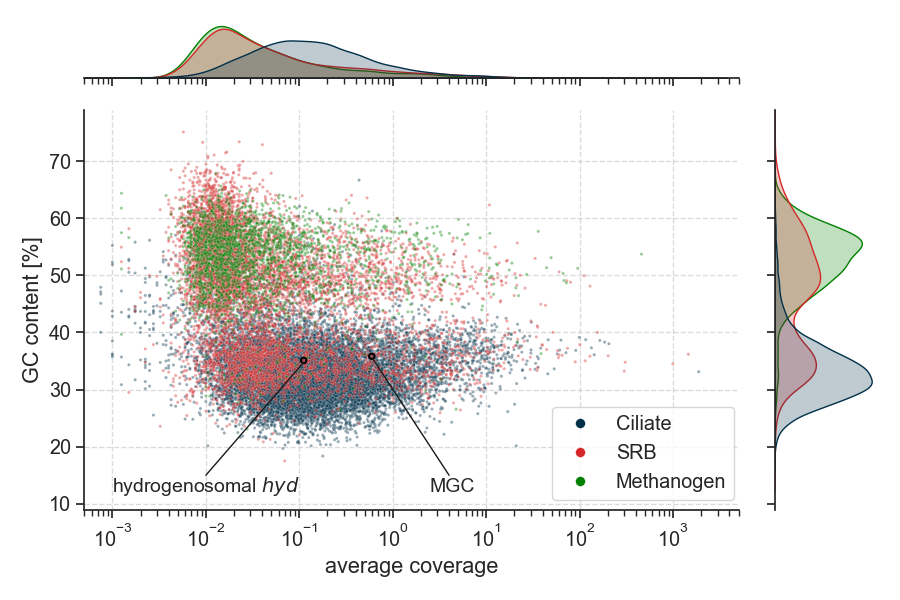

In [13]:
g = sns.jointplot(df[df['TPM next4'] != 0], x='TPM next4', y='GC', hue='type',
                  joint_kws={'s': 5, 'alpha': 0.4}, 
                  # common_norm scales sum of all areas to 1. if False, each area is scaled to 1.
                  marginal_kws={'log_scale': (True, False), 'common_norm': False, 'fill': True},
                  palette=sns.color_palette(["#003049", "#d62828", "green"]), height=7)

# MGC contig
g.ax_joint.scatter(mgc_cv, mgc_gc, s=15, facecolors='none', edgecolors='black', alpha=1, linewidth=1.5)
g.ax_joint.annotate("MGC", (mgc_cv, mgc_gc), fontsize=14, xytext=(2.5, 12), ha='left')
g.ax_joint.plot([mgc_cv + 0.01, 4], [mgc_gc - 0.35, 15], c='k', lw=1)

# hyd contig
g.ax_joint.scatter(hyd_cv1, hyd_gc,s=15,facecolors='none', edgecolors='black', alpha=1, linewidth=1.5)
g.ax_joint.annotate("hydrogenosomal $\it{hyd}$", (hyd_cv1, hyd_gc), fontsize=14, xytext=(1e-3, 12), ha='left')
g.ax_joint.plot([hyd_cv1, 1e-2], [hyd_gc - 0.35, 15], c='k', lw=1)

# plot settings
g.ax_marg_y.set_xscale('linear')
g.ax_joint.set_xscale('log')
g.ax_joint.set_xlim([5e-4, 5e3])
g.ax_joint.set_ylim([9, 79])
g.ax_joint.set_xlabel('average coverage')
g.ax_joint.set_ylabel('GC content [%]')
plt.grid(ls='--', alpha=0.7)

# legend
sns.move_legend(g.ax_joint, loc='lower left', bbox_to_anchor=[0.7, 0], title='', frameon=True)
for lh in g.ax_joint.legend_.legend_handles: 
    lh.set_alpha(1)
    lh.set_markersize(7)

# figure settings
g.fig.set_figwidth(9)
g.fig.set_figheight(6)
g.fig.tight_layout()

# save settings
plt.savefig('fig3_panelA.png', dpi=300)
plt.savefig('fig3_panelA.pdf', dpi=300)
plt.savefig('fig3_panelA.svg')

## Panel B: Metatranscriptomes

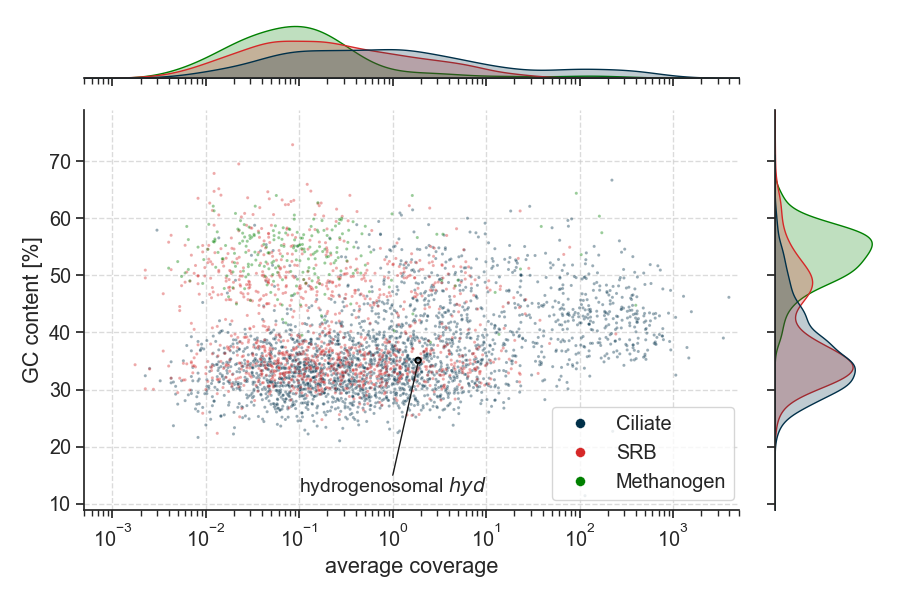

In [14]:
g = sns.jointplot(df[df['TPM first4'] != 0], x='TPM first4', y='GC', hue='type',
                  joint_kws={'s': 5, 'alpha': 0.4}, 
                  # common_norm scales sum of all areas to 1. if False, each area is scaled to 1.
                  marginal_kws={'log_scale': (True, False), 'common_norm': False, 'fill': True},
                  palette=sns.color_palette(["#003049", "#d62828", "green"]), height=7)

# hyd contig
g.ax_joint.scatter(hyd_cv2, hyd_gc, s=15, facecolors='none', edgecolors='black', alpha=1, linewidth=1.5)
g.ax_joint.annotate("hydrogenosomal $\it{hyd}$", (hyd_cv2, hyd_gc), fontsize=14, xytext=(1e-1, 12), ha='left')
g.ax_joint.plot([hyd_cv2 + 0.001, 1e0], [hyd_gc - 0.35, 15], c='k', lw=1)

# plot settings
g.ax_marg_y.set_xscale('linear')
g.ax_joint.set_xscale('log')
g.ax_joint.set_xlim([5e-4, 5e3])
g.ax_joint.set_ylim([9, 79])
g.ax_joint.set_xlabel('average coverage')
g.ax_joint.set_ylabel('GC content [%]')
plt.grid(ls='--', alpha=0.7)

# legend
sns.move_legend(g.ax_joint, loc='lower left', bbox_to_anchor=[0.7, 0], title='', frameon=True)
for lh in g.ax_joint.legend_.legend_handles: 
    lh.set_alpha(1)
    lh.set_markersize(7)

# figure settings
g.fig.set_figwidth(9)
g.fig.set_figheight(6)
g.fig.tight_layout()

# save settings
plt.savefig('fig3_panelB.png', dpi=300)
plt.savefig('fig3_panelB.pdf', dpi=300)
plt.savefig('fig3_panelB.svg')